In [18]:
import polars as pl

DATA_GLOB = "data/subset_part_*.parquet"  

In [19]:
lf = pl.scan_parquet(DATA_GLOB)

print("Schema:")
print(lf.schema)

print("Row count:")
print(lf.select(pl.len().alias("n_rows")).collect())


Schema:
Schema({'reviewerID': String, 'unixReviewTime': Int64, 'year': Int64, 'overall': Float64, 'asin': String, 'verified': Boolean, 'summary': String, 'reviewText': String})
Row count:
shape: (1, 1)
┌────────┐
│ n_rows │
│ ---    │
│ u32    │
╞════════╡
│ 200000 │
└────────┘


/var/folders/jc/m5_dzhb94fsdm0nt78jxzpx00000gn/T/ipykernel_1142/2055788536.py:4: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(lf.schema)


In [20]:
lf = lf.with_columns(
    pl.from_epoch("unixReviewTime", time_unit="s").alias("review_dt")
)

In [21]:
overview = lf.select([
    pl.len().alias("n_reviews"),
    pl.col("reviewerID").n_unique().alias("n_users"),
    pl.col("asin").n_unique().alias("n_products"),
    pl.min("year").alias("min_year"),
    pl.max("year").alias("max_year"),
]).collect()

print(overview)


shape: (1, 5)
┌───────────┬─────────┬────────────┬──────────┬──────────┐
│ n_reviews ┆ n_users ┆ n_products ┆ min_year ┆ max_year │
│ ---       ┆ ---     ┆ ---        ┆ ---      ┆ ---      │
│ u32       ┆ u32     ┆ u32        ┆ i64      ┆ i64      │
╞═══════════╪═════════╪════════════╪══════════╪══════════╡
│ 200000    ┆ 125233  ┆ 94636      ┆ 2018     ┆ 2018     │
└───────────┴─────────┴────────────┴──────────┴──────────┘


In [22]:
missing = lf.select([
    pl.all().null_count()
]).collect()
print(missing)


shape: (1, 9)
┌────────────┬────────────────┬──────┬─────────┬───┬──────────┬─────────┬────────────┬───────────┐
│ reviewerID ┆ unixReviewTime ┆ year ┆ overall ┆ … ┆ verified ┆ summary ┆ reviewText ┆ review_dt │
│ ---        ┆ ---            ┆ ---  ┆ ---     ┆   ┆ ---      ┆ ---     ┆ ---        ┆ ---       │
│ u32        ┆ u32            ┆ u32  ┆ u32     ┆   ┆ u32      ┆ u32     ┆ u32        ┆ u32       │
╞════════════╪════════════════╪══════╪═════════╪═══╪══════════╪═════════╪════════════╪═══════════╡
│ 0          ┆ 0              ┆ 0    ┆ 0       ┆ … ┆ 0        ┆ 106     ┆ 284        ┆ 0         │
└────────────┴────────────────┴──────┴─────────┴───┴──────────┴─────────┴────────────┴───────────┘


In [23]:
print(lf.group_by("overall").agg(pl.len().alias("n")).sort("overall").collect())
print(lf.group_by("year").agg(pl.len().alias("n")).sort("year").collect())


shape: (5, 2)
┌─────────┬────────┐
│ overall ┆ n      │
│ ---     ┆ ---    │
│ f64     ┆ u32    │
╞═════════╪════════╡
│ 1.0     ┆ 21204  │
│ 2.0     ┆ 10295  │
│ 3.0     ┆ 13762  │
│ 4.0     ┆ 22904  │
│ 5.0     ┆ 131835 │
└─────────┴────────┘
shape: (1, 2)
┌──────┬────────┐
│ year ┆ n      │
│ ---  ┆ ---    │
│ i64  ┆ u32    │
╞══════╪════════╡
│ 2018 ┆ 200000 │
└──────┴────────┘


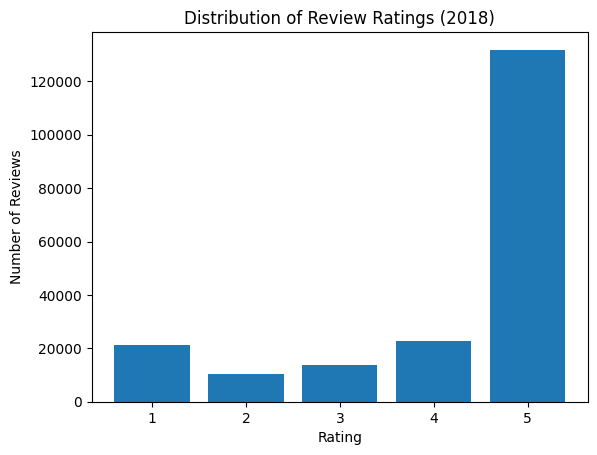

In [32]:
import matplotlib.pyplot as plt

rating_counts = (
    lf.group_by("overall")
      .agg(pl.len().alias("n"))
      .sort("overall")
      .collect()
      .to_pandas()
)

plt.figure()
plt.bar(rating_counts["overall"], rating_counts["n"])
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Ratings (2018)")
plt.xticks([1, 2, 3, 4, 5])
plt.show()

In [24]:
user_counts = lf.group_by("reviewerID").agg(pl.len().alias("n_reviews"))

print(
    user_counts.select([
        pl.len().alias("total_users"),
        (pl.col("n_reviews") == 1).mean().alias("pct_one_review"),
        (pl.col("n_reviews") >= 2).mean().alias("pct_two_plus"),
        pl.col("n_reviews").median().alias("median_reviews_per_user"),
        pl.col("n_reviews").quantile(0.9).alias("p90_reviews_per_user"),
    ]).collect()
)


shape: (1, 5)
┌─────────────┬────────────────┬──────────────┬─────────────────────────┬──────────────────────┐
│ total_users ┆ pct_one_review ┆ pct_two_plus ┆ median_reviews_per_user ┆ p90_reviews_per_user │
│ ---         ┆ ---            ┆ ---          ┆ ---                     ┆ ---                  │
│ u32         ┆ f64            ┆ f64          ┆ f64                     ┆ f64                  │
╞═════════════╪════════════════╪══════════════╪═════════════════════════╪══════════════════════╡
│ 125233      ┆ 0.724442       ┆ 0.275558     ┆ 1.0                     ┆ 3.0                  │
└─────────────┴────────────────┴──────────────┴─────────────────────────┴──────────────────────┘


In [25]:
# First review date per user
first = (
    lf.group_by("reviewerID")
      .agg(pl.col("review_dt").min().alias("first_review_dt"))
)

NEW_DAYS = 90

lf2 = (
    lf.join(first, on="reviewerID", how="inner")
      .with_columns(
          (pl.col("review_dt") - pl.col("first_review_dt")).dt.total_days().alias("account_age_days")
      )
)

new_user_reviews = lf2.filter(pl.col("account_age_days") <= NEW_DAYS)

# Early vs late windows (within first 90 days)
early_end = 30
late_start, late_end = 60, 90

user_change = (
    new_user_reviews
      .with_columns(
          pl.when(pl.col("account_age_days") <= early_end).then(pl.lit("early"))
            .when((pl.col("account_age_days") >= late_start) & (pl.col("account_age_days") <= late_end)).then(pl.lit("late"))
            .otherwise(None)
            .alias("period")
      )
      .filter(pl.col("period").is_not_null())
      .group_by(["reviewerID", "period"])
      .agg(pl.mean("overall").alias("avg_rating"))
      .collect()  # pivot happens on eager DF
      .pivot(index="reviewerID", columns="period", values="avg_rating")
      .drop_nulls(["early", "late"])  # keep only users with both 
      .with_columns((pl.col("late") - pl.col("early")).alias("delta_rating"))
)

print(
    user_change.select([
        pl.len().alias("n_users_with_both_windows"),
        pl.col("delta_rating").mean().alias("mean_delta"),
        pl.col("delta_rating").median().alias("median_delta"),
        pl.col("delta_rating").quantile(0.25).alias("q25"),
        pl.col("delta_rating").quantile(0.75).alias("q75"),
    ])
)


shape: (1, 5)
┌───────────────────────────┬────────────┬──────────────┬───────────┬─────┐
│ n_users_with_both_windows ┆ mean_delta ┆ median_delta ┆ q25       ┆ q75 │
│ ---                       ┆ ---        ┆ ---          ┆ ---       ┆ --- │
│ u32                       ┆ f64        ┆ f64          ┆ f64       ┆ f64 │
╞═══════════════════════════╪════════════╪══════════════╪═══════════╪═════╡
│ 3661                      ┆ 0.017225   ┆ 0.0          ┆ -0.166667 ┆ 0.5 │
└───────────────────────────┴────────────┴──────────────┴───────────┴─────┘


/var/folders/jc/m5_dzhb94fsdm0nt78jxzpx00000gn/T/ipykernel_1142/2066555837.py:34: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(index="reviewerID", columns="period", values="avg_rating")


In [26]:
# summary stats:
summary = user_change.select([
    pl.len().alias("n_users"),
    pl.col("early").mean().alias("mean_early"),
    pl.col("late").mean().alias("mean_late"),
    pl.col("delta_rating").mean().alias("mean_delta"),
    pl.col("delta_rating").median().alias("median_delta"),
    pl.col("delta_rating").std().alias("sd_delta"),
    (pl.col("delta_rating") > 0).mean().alias("pct_improve"),
    (pl.col("delta_rating") < 0).mean().alias("pct_decline"),
    (pl.col("delta_rating") == 0).mean().alias("pct_no_change"),
    pl.col("delta_rating").quantile(0.25).alias("q25"),
    pl.col("delta_rating").quantile(0.75).alias("q75"),
]).to_pandas()

print(summary)

   n_users  mean_early  mean_late  mean_delta  median_delta  sd_delta  \
0     3661    4.261658   4.278883    0.017225           0.0  1.472504   

   pct_improve  pct_decline  pct_no_change       q25  q75  
0     0.283802     0.253756       0.462442 -0.166667  0.5  


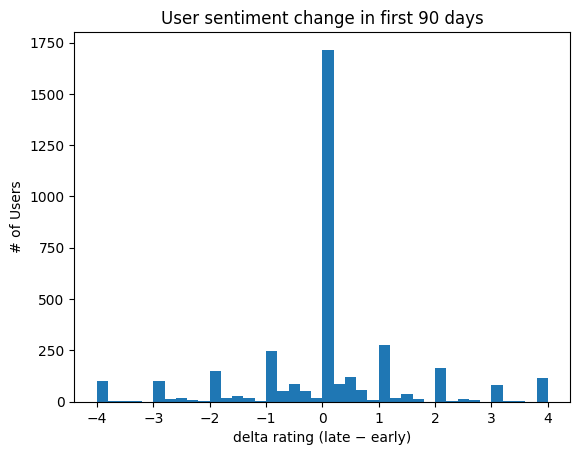

In [27]:
# Plot the distribution of rating changes (deltas)
import matplotlib.pyplot as plt

delta = user_change.select("delta_rating").to_pandas()["delta_rating"]

plt.figure()
plt.hist(delta, bins=40)
plt.xlabel("delta rating (late − early)")
plt.ylabel("# of Users")
plt.title("User sentiment change in first 90 days")
plt.show()

In [28]:
# Statistical Test
# Determine if mean delta differs from 0 (t-test)
from scipy import stats

delta = user_change.select("delta_rating").to_pandas()["delta_rating"]

t_stat, p_val = stats.ttest_1samp(delta, 0)

print("t-stat:", t_stat)
print("p-value:", p_val)


t-stat: 0.7077993525348045
p-value: 0.4791149372013689


In [29]:
# Add first review per user
first_ratings = (
    lf
    .sort(["reviewerID", "review_dt"])
    .group_by("reviewerID")
    .agg(pl.first("overall").alias("first_rating"))
    .collect()
)

In [30]:
# Group by first rating
analysis = (
    user_change
    .join(first_ratings, on="reviewerID")
    .group_by("first_rating")
    .agg([
        pl.len().alias("n"),
        pl.col("delta_rating").mean().alias("mean_delta"),
        pl.col("delta_rating").median().alias("median_delta"),
        (pl.col("delta_rating") > 0).mean().alias("pct_improve"),
        (pl.col("delta_rating") < 0).mean().alias("pct_decline")
    ])
    .sort("first_rating")
)

print(analysis)

shape: (5, 6)
┌──────────────┬──────┬────────────┬──────────────┬─────────────┬─────────────┐
│ first_rating ┆ n    ┆ mean_delta ┆ median_delta ┆ pct_improve ┆ pct_decline │
│ ---          ┆ ---  ┆ ---        ┆ ---          ┆ ---         ┆ ---         │
│ f64          ┆ u32  ┆ f64        ┆ f64          ┆ f64         ┆ f64         │
╞══════════════╪══════╪════════════╪══════════════╪═════════════╪═════════════╡
│ 1.0          ┆ 312  ┆ 2.230118   ┆ 2.5          ┆ 0.775641    ┆ 0.051282    │
│ 2.0          ┆ 167  ┆ 1.394582   ┆ 1.5          ┆ 0.748503    ┆ 0.143713    │
│ 3.0          ┆ 274  ┆ 0.687318   ┆ 1.0          ┆ 0.718978    ┆ 0.222628    │
│ 4.0          ┆ 459  ┆ 0.124304   ┆ 0.5          ┆ 0.586057    ┆ 0.261438    │
│ 5.0          ┆ 2449 ┆ -0.453659  ┆ 0.0          ┆ 0.084116    ┆ 0.289098    │
└──────────────┴──────┴────────────┴──────────────┴─────────────┴─────────────┘


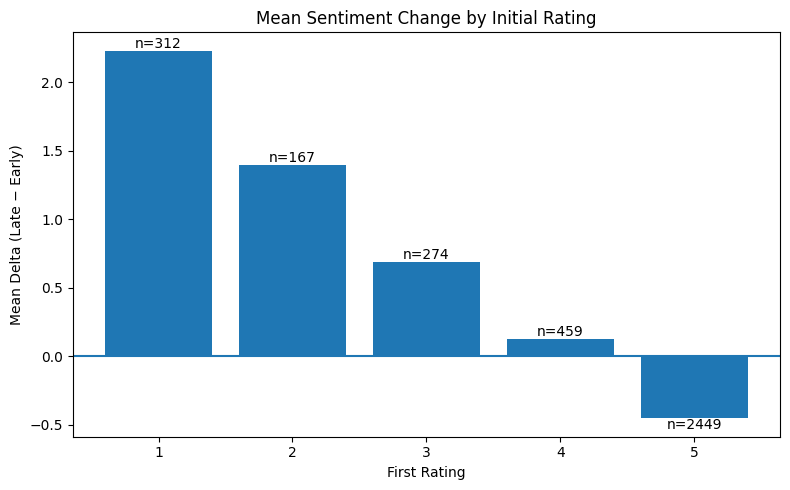

In [31]:
import matplotlib.pyplot as plt

# Convert to pandas for plotting
analysis_pd = analysis.to_pandas()

# Sort by first_rating just to be safe
analysis_pd = analysis_pd.sort_values("first_rating")

plt.figure(figsize=(8, 5))

bars = plt.bar(
    analysis_pd["first_rating"].astype(int),
    analysis_pd["mean_delta"]
)

# Horizontal line at zero
plt.axhline(0)

# Add sample size labels above bars
for i, row in analysis_pd.iterrows():
    plt.text(
        row["first_rating"],
        row["mean_delta"],
        f'n={int(row["n"])}',
        ha='center',
        va='bottom' if row["mean_delta"] >= 0 else 'top'
    )

plt.xlabel("First Rating")
plt.ylabel("Mean Delta (Late − Early)")
plt.title("Mean Sentiment Change by Initial Rating")
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()